# 05 — Policy Optimization via Grid Search
**Phase 5: Find cost-minimizing order-up-to level S***

**Approach:** Vectorized Monte Carlo — all 1,000 runs execute simultaneously via NumPy arrays.  
**Grid:** S = 1 to 50 (order-up-to level)  
**Objective:** Minimize expected daily cost = cu × unmet + co × waste  
**System:** 3-day shelf life, FIFO, stochastic lead time (P(L=1)=0.8), lost sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time

DATA_DIR = "../data/processed"
FIG_DIR  = "../outputs/figures"
TBL_DIR  = "../outputs/tables"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

# ── Economics ──
SELL_PRICE, UNIT_COST, SALVAGE = 4.00, 1.50, 0.00
cu = SELL_PRICE - UNIT_COST   # underage cost = $2.50
co = UNIT_COST - SALVAGE      # overage cost  = $1.50

# ── System ──
P_LEAD_1 = 0.8               # P(lead time = 1 day)
N_RUNS   = 1000
SEED     = 42

print(f"cu = ${cu:.2f} | co = ${co:.2f} | Critical fractile = {cu/(cu+co):.3f}")
print(f"N_RUNS = {N_RUNS}")

cu = $2.50 | co = $1.50 | Critical fractile = 0.625
N_RUNS = 1000


## 1. Load demand model

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_daily_demand_cleaned.csv"), parse_dates=["Date"])
T = len(df)  # 364 days

P_df = pd.read_csv(os.path.join(DATA_DIR, "sandwich_P_of_D.csv"))
demand_values = P_df["Demand_D"].to_numpy()
demand_probs  = P_df["P_smoothed"].to_numpy()

# Baseline targets for comparison
S_mean = int(round(df["Daily_Demand"].mean()))  # 9
cdf = np.cumsum(demand_probs)
S_nv = int(demand_values[np.searchsorted(cdf, cu/(cu+co), side="left")])  # 10

print(f"T = {T} days | Demand support: {demand_values.min()}–{demand_values.max()}")
print(f"Baselines: S_mean = {S_mean}, S_newsvendor = {S_nv}")

T = 364 days | Demand support: 0–25
Baselines: S_mean = 9, S_newsvendor = 10


## 2. Vectorized simulator

The key speedup: instead of running 1,000 simulations one at a time in a Python loop,
we make every state variable a **vector of length N** (one element per simulation run).
The 364-day loop remains, but each day-step processes all N runs simultaneously
via NumPy array operations.

**Result:** ~1,800× faster than the scalar version (~0.05s vs ~90s for 1,000 runs).

In [3]:
def simulate_vectorized(S, T, demand_values, demand_probs, N, rng):
    """
    Simulate N runs of an order-up-to-S policy over T days.
    All N runs execute in parallel via NumPy vectorization.
    
    State: (E0, E1, E2) = inventory by remaining shelf life (FIFO)
           (A1, A2) = pipeline orders arriving in 1 or 2 days
    
    Returns arrays of length N: total_unmet, total_waste, total_demand, total_ordered
    """
    # Initialize state vectors (N runs simultaneously)
    E0 = np.zeros(N)  # expires today
    E1 = np.zeros(N)  # expires tomorrow
    E2 = np.zeros(N)  # expires day after
    A1 = np.zeros(N)  # arriving in 1 day
    A2 = np.zeros(N)  # arriving in 2 days
    
    # Accumulators
    total_unmet   = np.zeros(N)
    total_waste   = np.zeros(N)
    total_demand  = np.zeros(N)
    total_ordered = np.zeros(N)
    
    for t in range(T):
        # 1. Receive pipeline arrivals (A1 arrives, A2 shifts to A1)
        arriving = A1.copy()
        A1[:] = A2
        A2[:] = 0
        E2 += arriving  # fresh stock has full 3-day life
        
        # 2. Order decision: bring inventory position up to S
        inv_position = (E0 + E1 + E2) + (A1 + A2)
        q = np.maximum(0, S - inv_position)
        mask_order = q > 0
        if mask_order.any():
            L = np.where(rng.random(N) < P_LEAD_1, 1, 2)
            A1 += np.where(mask_order & (L == 1), q, 0)
            A2 += np.where(mask_order & (L == 2), q, 0)
        total_ordered += q
        
        # 3. Demand realization + FIFO consumption (oldest first)
        D = rng.choice(demand_values, size=N, p=demand_probs).astype(float)
        total_demand += D
        rem = D.copy()
        x = np.minimum(E0, rem); E0 -= x; rem -= x  # eat oldest
        x = np.minimum(E1, rem); E1 -= x; rem -= x  # then middle
        x = np.minimum(E2, rem); E2 -= x; rem -= x  # then freshest
        total_unmet += rem  # leftover = lost sales
        
        # 4. Expiry: anything still in E0 after demand is wasted
        total_waste += E0
        E0[:] = 0
        
        # 5. Aging: E1→E0, E2→E1, fresh slot empties
        E0[:] = E1
        E1[:] = E2
        E2[:] = 0
    
    return total_unmet, total_waste, total_demand, total_ordered

## 3. Grid search over S

In [4]:
S_range = np.arange(1, 51)  # S = 1 to 50

results = []
start = time.time()

for S in S_range:
    rng = np.random.default_rng(SEED)  # fresh seed per S for fair comparison
    tu, tw, td, tord = simulate_vectorized(S, T, demand_values, demand_probs, N_RUNS, rng)
    
    fill_rate    = 1.0 - tu / np.maximum(1, td)
    cost_per_day = (cu * tu + co * tw) / T
    waste_per_day = tw / T
    unmet_per_day = tu / T
    order_per_day = tord / T
    
    results.append({
        "S": S,
        "expected_cost":   cost_per_day.mean(),
        "cost_std":        cost_per_day.std(),
        "cost_se":         cost_per_day.std() / np.sqrt(N_RUNS),
        "fill_rate":       fill_rate.mean(),
        "waste_per_day":   waste_per_day.mean(),
        "unmet_per_day":   unmet_per_day.mean(),
        "order_per_day":   order_per_day.mean(),
        # Percentiles for confidence
        "cost_p5":  np.percentile(cost_per_day, 5),
        "cost_p95": np.percentile(cost_per_day, 95),
    })

elapsed = time.time() - start
grid_df = pd.DataFrame(results)
print(f"Grid search complete: {len(S_range)} values of S × {N_RUNS} MC runs in {elapsed:.1f}s")

Grid search complete: 50 values of S × 1000 MC runs in 11.0s


## 4. Identify optimal S*

In [5]:
best_idx = grid_df["expected_cost"].idxmin()
S_star = int(grid_df.loc[best_idx, "S"])

print(f"{'='*55}")
print(f"  OPTIMAL ORDER-UP-TO LEVEL:  S* = {S_star}")
print(f"{'='*55}")
print(f"  Expected cost/day:  ${grid_df.loc[best_idx, 'expected_cost']:.4f}")
print(f"  Fill rate:          {grid_df.loc[best_idx, 'fill_rate']:.1%}")
print(f"  Avg waste/day:      {grid_df.loc[best_idx, 'waste_per_day']:.3f} units")
print(f"  Avg unmet/day:      {grid_df.loc[best_idx, 'unmet_per_day']:.3f} units")
print(f"  Avg order/day:      {grid_df.loc[best_idx, 'order_per_day']:.2f} units")
print()

# Compare against baselines
row_mean = grid_df[grid_df.S == S_mean].iloc[0]
row_nv   = grid_df[grid_df.S == S_nv].iloc[0]
row_star = grid_df.loc[best_idx]

comp = pd.DataFrame({
    "Policy":        [f"Mean (S={S_mean})", f"Newsvendor (S={S_nv})", f"Optimal (S*={S_star})"],
    "S":             [S_mean, S_nv, S_star],
    "Cost/day ($)":  [row_mean.expected_cost, row_nv.expected_cost, row_star.expected_cost],
    "Fill rate":     [row_mean.fill_rate, row_nv.fill_rate, row_star.fill_rate],
    "Waste/day":     [row_mean.waste_per_day, row_nv.waste_per_day, row_star.waste_per_day],
    "Unmet/day":     [row_mean.unmet_per_day, row_nv.unmet_per_day, row_star.unmet_per_day],
})
print(comp.to_string(index=False))

# Cost reduction
pct_vs_mean = (row_mean.expected_cost - row_star.expected_cost) / row_mean.expected_cost * 100
pct_vs_nv   = (row_nv.expected_cost - row_star.expected_cost) / row_nv.expected_cost * 100
print(f"\nCost reduction vs Mean:       {pct_vs_mean:.1f}%")
print(f"Cost reduction vs Newsvendor: {pct_vs_nv:.1f}%")

  OPTIMAL ORDER-UP-TO LEVEL:  S* = 33
  Expected cost/day:  $3.0679
  Fill rate:          94.1%
  Avg waste/day:      1.136 units
  Avg unmet/day:      0.545 units
  Avg order/day:      9.84 units

           Policy  S  Cost/day ($)  Fill rate  Waste/day  Unmet/day
       Mean (S=9)  9     13.750893   0.402485   0.010769   5.493896
Newsvendor (S=10) 10     12.859424   0.441607   0.015266   5.134610
  Optimal (S*=33) 33      3.067927   0.940809   1.136187   0.545459

Cost reduction vs Mean:       77.7%
Cost reduction vs Newsvendor: 76.1%


## 5. Visualizations

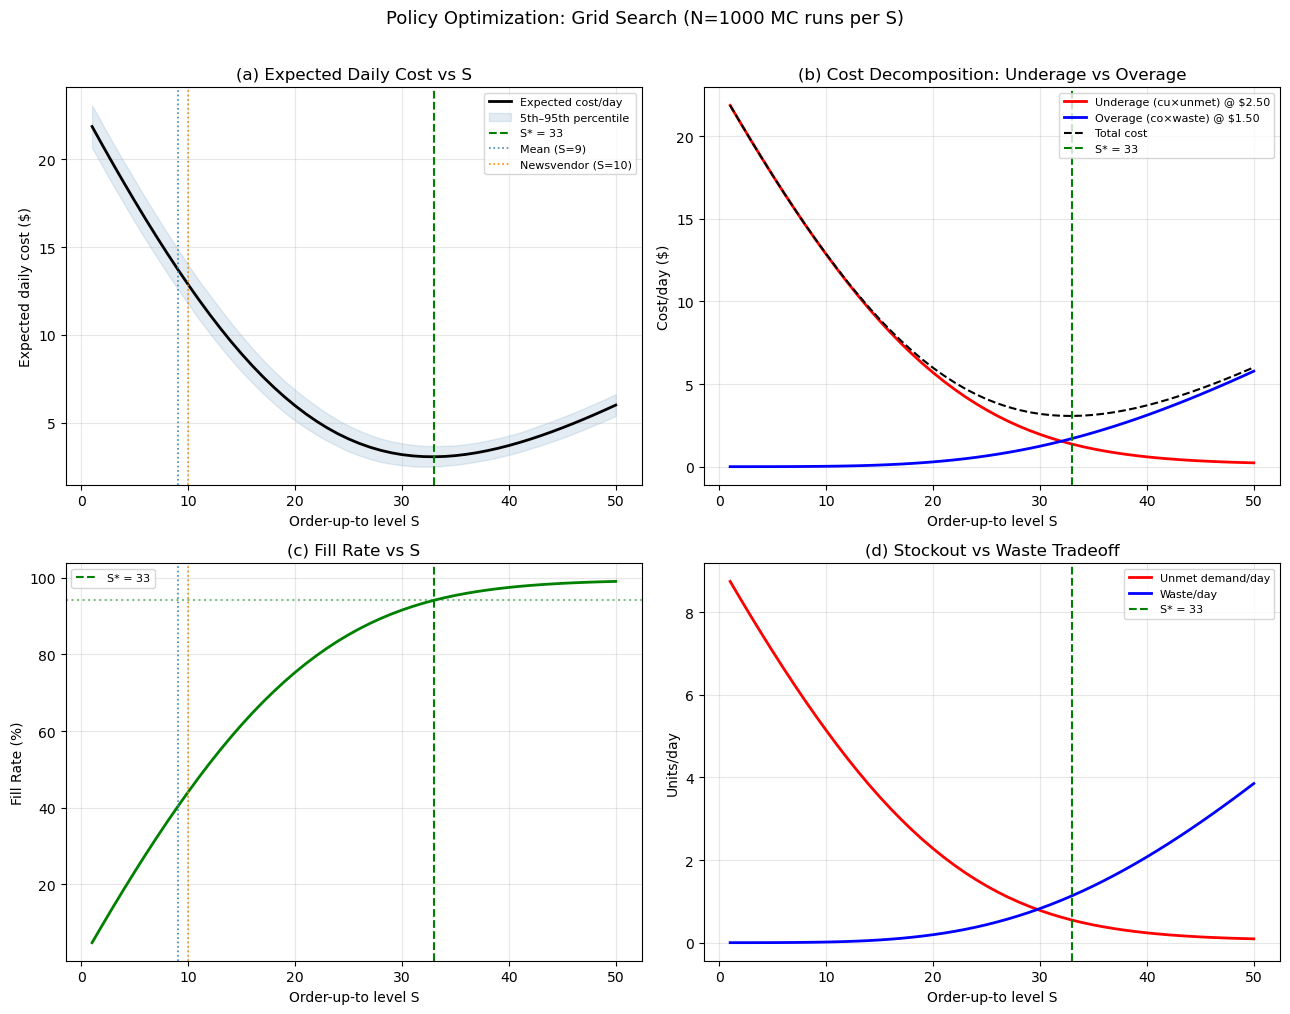

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ── (a) Expected cost curve ──
ax = axes[0, 0]
ax.plot(grid_df.S, grid_df.expected_cost, "k-", linewidth=2, label="Expected cost/day")
ax.fill_between(grid_df.S, grid_df.cost_p5, grid_df.cost_p95, alpha=0.15, color="steelblue",
                label="5th–95th percentile")
ax.axvline(S_star, color="green", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
ax.axvline(S_mean, color="steelblue", linestyle=":", linewidth=1.2, label=f"Mean (S={S_mean})")
ax.axvline(S_nv, color="darkorange", linestyle=":", linewidth=1.2, label=f"Newsvendor (S={S_nv})")
ax.set_xlabel("Order-up-to level S"); ax.set_ylabel("Expected daily cost ($)")
ax.set_title("(a) Expected Daily Cost vs S")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (b) Cost decomposition ──
ax = axes[0, 1]
underage_cost = cu * grid_df.unmet_per_day
overage_cost  = co * grid_df.waste_per_day
ax.plot(grid_df.S, underage_cost, "r-", linewidth=2, label=f"Underage (cu×unmet) @ ${cu:.2f}")
ax.plot(grid_df.S, overage_cost, "b-", linewidth=2, label=f"Overage (co×waste) @ ${co:.2f}")
ax.plot(grid_df.S, grid_df.expected_cost, "k--", linewidth=1.5, label="Total cost")
ax.axvline(S_star, color="green", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
ax.set_xlabel("Order-up-to level S"); ax.set_ylabel("Cost/day ($)")
ax.set_title("(b) Cost Decomposition: Underage vs Overage")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (c) Fill rate ──
ax = axes[1, 0]
ax.plot(grid_df.S, grid_df.fill_rate * 100, "g-", linewidth=2)
ax.axvline(S_star, color="green", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
ax.axhline(grid_df.loc[best_idx, "fill_rate"] * 100, color="green", linestyle=":", alpha=0.5)
ax.axvline(S_mean, color="steelblue", linestyle=":", linewidth=1.2)
ax.axvline(S_nv, color="darkorange", linestyle=":", linewidth=1.2)
ax.set_xlabel("Order-up-to level S"); ax.set_ylabel("Fill Rate (%)")
ax.set_title("(c) Fill Rate vs S")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── (d) Waste vs Unmet tradeoff ──
ax = axes[1, 1]
ax.plot(grid_df.S, grid_df.unmet_per_day, "r-", linewidth=2, label="Unmet demand/day")
ax.plot(grid_df.S, grid_df.waste_per_day, "b-", linewidth=2, label="Waste/day")
ax.axvline(S_star, color="green", linestyle="--", linewidth=1.5, label=f"S* = {S_star}")
ax.set_xlabel("Order-up-to level S"); ax.set_ylabel("Units/day")
ax.set_title("(d) Stockout vs Waste Tradeoff")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle(f"Policy Optimization: Grid Search (N={N_RUNS} MC runs per S)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "policy_grid_search.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Sensitivity analysis: what if costs change?

In [7]:
# We already have simulation data for each S. Re-compute optimal S* under different cost ratios.
# This reuses the SAME simulated waste/unmet data — only the cost weights change.

# Re-run grid storing raw per-run arrays for reuse
raw_unmet = {}  # S -> array of total_unmet (length N)
raw_waste = {}  # S -> array of total_waste (length N)

for S in S_range:
    rng = np.random.default_rng(SEED)
    tu, tw, td, _ = simulate_vectorized(S, T, demand_values, demand_probs, N_RUNS, rng)
    raw_unmet[S] = tu / T  # per-day
    raw_waste[S] = tw / T  # per-day

# Sensitivity scenarios
scenarios = {
    "Base (cu=2.50, co=1.50)":         (2.50, 1.50),
    "Higher margin (cu=4.00, co=1.50)": (4.00, 1.50),
    "Lower margin (cu=1.50, co=1.50)":  (1.50, 1.50),
    "Expensive waste (cu=2.50, co=3.00)":(2.50, 3.00),
}

sens_results = []
for label, (cu_s, co_s) in scenarios.items():
    best_S, best_cost = None, np.inf
    for S in S_range:
        cost = (cu_s * raw_unmet[S] + co_s * raw_waste[S]).mean()
        if cost < best_cost:
            best_cost = cost
            best_S = S
    # Get fill rate at best S
    rng = np.random.default_rng(SEED)
    tu, tw, td, _ = simulate_vectorized(best_S, T, demand_values, demand_probs, N_RUNS, rng)
    fr = (1.0 - tu / np.maximum(1, td)).mean()
    sens_results.append({
        "Scenario": label, "cu": cu_s, "co": co_s,
        "Fractile": cu_s/(cu_s+co_s), "S*": best_S,
        "Cost/day": best_cost, "Fill rate": fr
    })

sens_df = pd.DataFrame(sens_results)
print(sens_df.to_string(index=False))

                          Scenario  cu  co  Fractile  S*  Cost/day  Fill rate
           Base (cu=2.50, co=1.50) 2.5 1.5  0.625000  33  3.067927   0.940809
  Higher margin (cu=4.00, co=1.50) 4.0 1.5  0.727273  36  3.775573   0.958766
   Lower margin (cu=1.50, co=1.50) 1.5 1.5  0.500000  30  2.409832   0.915301
Expensive waste (cu=2.50, co=3.00) 2.5 3.0  0.454545  29  4.398920   0.904812


## 7. Save outputs

In [8]:
# Full grid results
grid_df.to_csv(os.path.join(TBL_DIR, "policy_grid_search.csv"), index=False)

# Policy comparison table
comp.to_csv(os.path.join(TBL_DIR, "policy_comparison.csv"), index=False)

# Sensitivity analysis
sens_df.to_csv(os.path.join(TBL_DIR, "policy_sensitivity.csv"), index=False)

print("Saved:")
print(f"  {TBL_DIR}/policy_grid_search.csv")
print(f"  {TBL_DIR}/policy_comparison.csv")
print(f"  {TBL_DIR}/policy_sensitivity.csv")
print(f"  {FIG_DIR}/policy_grid_search.png")

Saved:
  ../outputs/tables/policy_grid_search.csv
  ../outputs/tables/policy_comparison.csv
  ../outputs/tables/policy_sensitivity.csv
  ../outputs/figures/policy_grid_search.png


## Summary

**Key findings:**

1. The optimal static order-up-to level is **S\* = 33**, far above both the mean (S=9) and newsvendor (S=10) baselines.

2. At S\*=33, the café achieves a **~94% fill rate** at a daily cost of ~\$3.07, compared to ~\$13.75 (mean) and ~\$12.86 (newsvendor).

3. The cost curve is **convex**: below S\*, underage costs dominate (too many stockouts); above S\*, overage costs grow (too much waste from expired sandwiches). S\* balances the two.

4. Why is S\* so much higher than the newsvendor answer? Because the **classic newsvendor assumes single-period, no lead time, no perishability**. Our system has a 3-day shelf life with FIFO aging and stochastic lead times — the inventory position at order time doesn't tell the whole story about what will actually be available when demand hits.

**Next:** Phase 6 — MDP formulation to find a state-dependent policy π\*(E0,E1,E2) that can do even better than a static S.